In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import gc
from typing import Dict, List, Tuple, Optional
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [141]:
# improts for advanced EDA
import dask.dataframe as dd
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import duckdb
import os
from dask.diagnostics import ProgressBar

In [142]:
# Configuration for memory optimization
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Memory optimization settings
CHUNK_SIZE = 30000  # Reduced for M4 MacBook
MAX_CATEGORIES = 50  # Limit categorical analysis


In [145]:
class MemoryOptimizedLoader:
    """Optimized data loader for large datasets"""
    
    @staticmethod
    def load_chunked_csv(filepath: str, chunk_size: int = CHUNK_SIZE) -> Optional[pd.DataFrame]:
        """Load large CSV in memory-efficient chunks"""
        try:
            print(f"Loading {filepath} in chunks of {chunk_size}...")
            chunks = []
            total_rows = 0
            
            for chunk in pd.read_csv(filepath, chunksize=chunk_size, low_memory=False):
                # Basic cleaning during load
                chunk = chunk.dropna(subset=['Year', 'USD_Disbursement'])
                chunks.append(chunk)
                total_rows += len(chunk)
                
                if len(chunks) % 10 == 0:
                    print(f"Processed {total_rows:,} rows...")
            
            df = pd.concat(chunks, ignore_index=True)
            print(f"Successfully loaded {len(df):,} rows")
            return df
            
        except FileNotFoundError:
            print(f"Error: File {filepath} not found")
            return None
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return None
    
    @staticmethod
    def optimize_dtypes(df: pd.DataFrame) -> pd.DataFrame:
        """Optimize data types to reduce memory usage"""
        print("Optimizing data types...")
        initial_memory = df.memory_usage(deep=True).sum() / 1024**2
        
        # Convert numeric columns
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if df[col].dtype == 'float64':
                df[col] = pd.to_numeric(df[col], downcast='float')
            elif df[col].dtype == 'int64':
                df[col] = pd.to_numeric(df[col], downcast='integer')
        
        # Convert categorical columns
        categorical_threshold = 0.5
        for col in df.select_dtypes(include=['object']).columns:
            if len(df[col].unique()) / len(df) < categorical_threshold:
                df[col] = df[col].astype('category')
        
        final_memory = df.memory_usage(deep=True).sum() / 1024**2
        print(f"Memory usage reduced from {initial_memory:.1f}MB to {final_memory:.1f}MB")
        print(f"Reduction: {((initial_memory - final_memory) / initial_memory * 100):.1f}%")
        
        return df


In [ ]:
# =============================================================================
# SECTION 1: DATA LOADING & PREPROCESSING
# =============================================================================



# Initialize data loader
loader = MemoryOptimizedLoader()

# Load main CRS dataset
print("\n1. LOADING PRIMARY DATASET (OECD CRS)")


crs_data = loader.load_chunked_csv('data/raw/crs/crs_data.csv')

if crs_data is not None:
    # Optimize memory usage
    crs_data = loader.optimize_dtypes(crs_data)
    
    print(f"\nCRS Dataset Overview:")
    print(f"Shape: {crs_data.shape}")
    print(f"Memory usage: {crs_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"Time range: {crs_data['Year'].min()} - {crs_data['Year'].max()}")




In [ ]:
# Load supplementary datasets
print("\n2. LOADING SUPPLEMENTARY DATASETS")



supplementary_data = {}

# ND-GAIN Climate data
try:
    gain_data = pd.read_csv('data/processed/ng_gain/nd_gain_data.csv')
    gain_data = loader.optimize_dtypes(gain_data)
    supplementary_data['gain'] = gain_data
    print(f"✓ ND-GAIN data loaded: {gain_data.shape}")
except Exception as e:
    print(f"✗ ND-GAIN data: {e}")

# UNDP HDR data
try:
    undp_data = pd.read_csv('data/processed/undp_hdr/undp_hdr_data.csv')
    undp_data = loader.optimize_dtypes(undp_data)
    supplementary_data['undp'] = undp_data
    print(f"✓ UNDP HDR data loaded: {undp_data.shape}")
except Exception as e:
    print(f"✗ UNDP HDR data: {e}")

# CCVI (Climate-Conflict vulneratbility index)
try:
    ccvi_data = pd.read_csv('data/processed/ccvi/ccvi_annual_country.csv')
    ccvi_data = loader.optimize_dtypes(ccvi_data)
    supplementary_data['ccvi'] = ccvi_data
    print(f"✓ CCVI data loaded: {ccvi_data.shape}")
except Exception as e:
    print(f"✗ CCVI data: {e}")


2. LOADING SUPPLEMENTARY DATASETS
Optimizing data types...
Memory usage reduced from 0.7MB to 0.1MB
Reduction: 83.6%
✓ ND-GAIN data loaded: (5423, 6)
Optimizing data types...
Memory usage reduced from 0.6MB to 0.2MB
Reduction: 70.1%
✓ UNDP HDR data loaded: (2060, 20)
Optimizing data types...
Memory usage reduced from 0.3MB to 0.1MB
Reduction: 70.9%
✓ CCVI data loaded: (1925, 9)


In [148]:
# =============================================================================
# SECTION 3: FEATURE ENGINEERING FOR SYNERGY ANALYSIS
# =============================================================================

if crs_data is not None:
    print("\n3. FEATURE ENGINEERING FOR SYNERGY ANALYSIS")
  
    
    # STEP 1: Identify correct disbursement column
    print("Identifying disbursement columns...")
    disbursement_cols = [col for col in crs_data.columns if any(keyword in col.lower() 
                        for keyword in ['disbursement', 'amount', 'usd', 'commitment'])]
    print(f"Available disbursement columns: {disbursement_cols}")
    
    # Find the main disbursement column
    main_disbursement_col = None
    priority_cols = ['USD_Disbursement', 'USD_Disbursement_Defl', 'Disbursement', 'USD_Commitment', 'USD_Amount']
    
    for col in priority_cols:
        if col in crs_data.columns:
            main_disbursement_col = col
            break
    
    if main_disbursement_col is None and disbursement_cols:
        main_disbursement_col = disbursement_cols[0]
    
    print(f"Using disbursement column: {main_disbursement_col}")
    
    # STEP 2: Clean and standardize disbursement data
    if main_disbursement_col:
        # Create standardized USD_Disbursement column
        crs_data['USD_Disbursement'] = pd.to_numeric(crs_data[main_disbursement_col], errors='coerce').fillna(0)
        
        # Diagnostic check
        print(f"\nDisbursement data diagnostics:")
        print(f"Data type: {crs_data['USD_Disbursement'].dtype}")
        print(f"Non-zero records: {(crs_data['USD_Disbursement'] > 0).sum():,}")
        print(f"Raw sum: {crs_data['USD_Disbursement'].sum():,.0f}")
        print(f"Sample values: {crs_data['USD_Disbursement'].head().tolist()}")
        
        # Handle potential unit issues
        raw_total = crs_data['USD_Disbursement'].sum()
        if raw_total > 0:
            print(f"Total in different units:")
            print(f"  As is: ${raw_total:,.0f}")
            print(f"  Thousands: ${raw_total/1e3:,.1f}K")
            print(f"  Millions: ${raw_total/1e6:,.1f}M") 
            print(f"  Billions: ${raw_total/1e9:,.1f}B")
        else:
            print("⚠️  Warning: All disbursement values are zero or invalid")
    
    # STEP 3: Clean and prepare policy markers
    print("\nCleaning policy markers...")
    policy_markers = ['Gender', 'Environment', 'ClimateMitigation', 'ClimateAdaptation']
    
    for marker in policy_markers:
        if marker in crs_data.columns:
            crs_data[marker] = pd.to_numeric(crs_data[marker], errors='coerce').fillna(0)
            print(f"✓ {marker}: {(crs_data[marker] > 0).sum():,} projects marked")
    
    # STEP 4: Create synergy indicators
    print("\nCreating synergy indicators...")
    
    # Climate marker (mitigation OR adaptation)
    crs_data['Climate_Marker'] = 0
    if 'ClimateMitigation' in crs_data.columns and 'ClimateAdaptation' in crs_data.columns:
        crs_data['Climate_Marker'] = ((crs_data['ClimateMitigation'] > 0) | 
                                     (crs_data['ClimateAdaptation'] > 0)).astype(int)
    elif 'ClimateMitigation' in crs_data.columns:
        crs_data['Climate_Marker'] = (crs_data['ClimateMitigation'] > 0).astype(int)
    elif 'Environment' in crs_data.columns:
        crs_data['Climate_Marker'] = (crs_data['Environment'] > 0).astype(int)
    
    # Gender marker
    crs_data['Gender_Marker'] = 0
    if 'Gender' in crs_data.columns:
        crs_data['Gender_Marker'] = (crs_data['Gender'] > 0).astype(int)
    
    # Synergy marker (both climate AND gender)
    crs_data['Synergy_Marker'] = (crs_data['Climate_Marker'] & crs_data['Gender_Marker']).astype(int)
    
    # STEP 5: Create prototype synergy score for ML model
    crs_data['Synergy_Score'] = (
        crs_data['Gender_Marker'] * 0.3 +
        crs_data['Climate_Marker'] * 0.3 +
        crs_data['Synergy_Marker'] * 0.4
    )
    
    print("✓ Created synergy indicators and prototype scoring")
    
    # STEP 6: Calculate comprehensive statistics
    total_projects = len(crs_data)
    synergy_projects = crs_data['Synergy_Marker'].sum()
    gender_projects = crs_data['Gender_Marker'].sum()
    climate_projects = crs_data['Climate_Marker'].sum()
    
    total_disbursement = crs_data['USD_Disbursement'].sum()
    synergy_disbursement = crs_data[crs_data['Synergy_Marker'] == 1]['USD_Disbursement'].sum()
    gender_disbursement = crs_data[crs_data['Gender_Marker'] == 1]['USD_Disbursement'].sum()
    climate_disbursement = crs_data[crs_data['Climate_Marker'] == 1]['USD_Disbursement'].sum()
    
    print(f"\nSYNERGY OVERVIEW:")
    print(f"Total projects: {total_projects:,}")
    print(f"Gender projects: {gender_projects:,} ({gender_projects/total_projects*100:.2f}%)")
    print(f"Climate projects: {climate_projects:,} ({climate_projects/total_projects*100:.2f}%)")
    print(f"Synergy projects: {synergy_projects:,} ({synergy_projects/total_projects*100:.2f}%)")
    
    if total_disbursement > 0:
        print(f"\nDISBURSEMENT ANALYSIS:")
        # Use thousands as the base unit since total is only ~3.2M
        print(f"Total disbursement: ${total_disbursement/1e3:.1f}K (${total_disbursement:,.0f})")
        print(f"Gender disbursement: ${gender_disbursement/1e3:.1f}K ({gender_disbursement/total_disbursement*100:.2f}%)")
        print(f"Climate disbursement: ${climate_disbursement/1e3:.1f}K ({climate_disbursement/total_disbursement*100:.2f}%)")
        print(f"Synergy disbursement: ${synergy_disbursement/1e3:.1f}K ({synergy_disbursement/total_disbursement*100:.2f}%)")
        
        # Average project sizes in actual dollars
        avg_synergy_size = synergy_disbursement / max(synergy_projects, 1)
        avg_regular_size = (total_disbursement - synergy_disbursement) / max(total_projects - synergy_projects, 1)
        
        print(f"\nPROJECT SIZE ANALYSIS:")
        print(f"Average synergy project size: ${avg_synergy_size:,.0f}")
        print(f"Average regular project size: ${avg_regular_size:,.0f}")
        if avg_regular_size > 0:
            print(f"Synergy premium: {(avg_synergy_size/avg_regular_size - 1)*100:.1f}%")
        else:
            print("Synergy premium: Cannot calculate (division by zero)")
    else:
        print("\n⚠️  Cannot calculate disbursement statistics - all values are zero")
        print("This suggests a data format issue that needs to be resolved")



3. FEATURE ENGINEERING FOR SYNERGY ANALYSIS
Identifying disbursement columns...
Available disbursement columns: ['USD_Commitment', 'USD_Disbursement', 'USD_Received', 'USD_Commitment_Defl', 'USD_Disbursement_Defl', 'USD_Received_Defl', 'USD_Adjustment', 'USD_Adjustment_Defl', 'USD_AmountUntied', 'USD_AmountPartialTied', 'USD_AmountTied', 'USD_AmountUntied_Defl', 'USD_AmountPartialTied_Defl', 'USD_Amounttied_Defl', 'USD_IRTC', 'USD_Expert_Commitment', 'USD_Expert_Extended', 'USD_Export_Credit', 'Commitment_National', 'Disbursement_National', 'USD_GrantEquiv', 'CommitmentDate', 'USD_Interest', 'USD_Outstanding', 'USD_Arrears_Principal', 'USD_Arrears_Interest']
Using disbursement column: USD_Disbursement

Disbursement data diagnostics:
Data type: float32
Non-zero records: 2,465,954
Raw sum: 3,159,876
Sample values: [0.16129200160503387, 1.953163981437683, 0.1055700033903122, 0.05050000175833702, 0.023120999336242676]
Total in different units:
  As is: $3,159,876
  Thousands: $3,159.9K
  

In [11]:
# =============================================================================
# SECTION 3: TEMPORAL ANALYSIS - KEY FOR FORECASTING
# =============================================================================

if crs_data is not None:
    print("\n4. TEMPORAL SYNERGY ANALYSIS")
    print("-" * 50)
    
    # Yearly aggregation for trend analysis
    yearly_analysis = crs_data.groupby('Year').agg({
        'USD_Disbursement': 'sum',
        'Gender_Marker': 'sum',
        'Climate_Marker': 'sum', 
        'Synergy_Marker': 'sum',
        'Synergy_Score': 'mean'
    }).reset_index()
    
    # Calculate weighted disbursements
    gender_disbursement = crs_data[crs_data['Gender_Marker'] == 1].groupby('Year')['USD_Disbursement'].sum()
    climate_disbursement = crs_data[crs_data['Climate_Marker'] == 1].groupby('Year')['USD_Disbursement'].sum()
    synergy_disbursement = crs_data[crs_data['Synergy_Marker'] == 1].groupby('Year')['USD_Disbursement'].sum()
    
    yearly_analysis = yearly_analysis.merge(gender_disbursement.rename('Gender_Disbursement'), 
                                          left_on='Year', right_index=True, how='left')
    yearly_analysis = yearly_analysis.merge(climate_disbursement.rename('Climate_Disbursement'), 
                                          left_on='Year', right_index=True, how='left')
    yearly_analysis = yearly_analysis.merge(synergy_disbursement.rename('Synergy_Disbursement'), 
                                          left_on='Year', right_index=True, how='left')
    
    yearly_analysis = yearly_analysis.fillna(0)
    
    # Calculate shares
    yearly_analysis['Synergy_Share'] = yearly_analysis['Synergy_Disbursement'] / yearly_analysis['USD_Disbursement']
    yearly_analysis['Gender_Share'] = yearly_analysis['Gender_Disbursement'] / yearly_analysis['USD_Disbursement']
    yearly_analysis['Climate_Share'] = yearly_analysis['Climate_Disbursement'] / yearly_analysis['USD_Disbursement']
    
    print("✓ Temporal analysis completed")


4. TEMPORAL SYNERGY ANALYSIS
--------------------------------------------------
✓ Temporal analysis completed


In [ ]:
# =============================================================================
# SECTION 4: COMPREHENSIVE VISUALIZATIONS
# =============================================================================

if crs_data is not None and len(yearly_analysis) > 0:
    print("\n5. CREATING COMPREHENSIVE VISUALIZATIONS")
    
    
    # 1. Synergy Trend Over Time
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Disbursement shares over time
    ax1.plot(yearly_analysis['Year'], yearly_analysis['Synergy_Share'] * 100, 
             marker='o', linewidth=3, label='Gender-Climate Synergy', color='#2ca02c')
    ax1.plot(yearly_analysis['Year'], yearly_analysis['Gender_Share'] * 100, 
             marker='s', linewidth=2, label='Gender Only', color='#ff7f0e', alpha=0.7)
    ax1.plot(yearly_analysis['Year'], yearly_analysis['Climate_Share'] * 100, 
             marker='^', linewidth=2, label='Climate Only', color='#1f77b4', alpha=0.7)
    
    ax1.set_title('Evolution of Cross-Sector Investment Shares', fontsize=14, weight='bold')
    ax1.set_ylabel('Share of Total Disbursement (%)')
    ax1.set_xlabel('Year')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Project count trends
    ax2.plot(yearly_analysis['Year'], yearly_analysis['Synergy_Marker'], 
             marker='o', linewidth=3, color='#2ca02c')
    ax2.set_title('Number of Synergy Projects Over Time', fontsize=14, weight='bold')
    ax2.set_ylabel('Number of Projects')
    ax2.set_xlabel('Year')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Average synergy score evolution
    ax3.plot(yearly_analysis['Year'], yearly_analysis['Synergy_Score'], 
             marker='o', linewidth=3, color='#d62728')
    ax3.set_title('Average Synergy Score Evolution', fontsize=14, weight='bold')
    ax3.set_ylabel('Average Synergy Score')
    ax3.set_xlabel('Year')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Total disbursement trend
    ax4.plot(yearly_analysis['Year'], yearly_analysis['USD_Disbursement'] / 1e9, 
             marker='o', linewidth=3, color='#9467bd')
    ax4.set_title('Total ODA Disbursement Trend', fontsize=14, weight='bold')
    ax4.set_ylabel('Disbursement (Billions USD)')
    ax4.set_xlabel('Year')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Sector Analysis for Synergy Projects
    if 'SectorName' in crs_data.columns:
        print("\nAnalyzing sector distribution for synergy projects...")
        
        synergy_sectors = (crs_data[crs_data['Synergy_Marker'] == 1]
                          .groupby('SectorName')['USD_Disbursement']
                          .sum().nlargest(15).reset_index())
        
        plt.figure(figsize=(14, 8))
        sns.barplot(data=synergy_sectors, y='SectorName', x='USD_Disbursement', 
                   palette='viridis_r')
        plt.title('Top 15 Sectors for Gender-Climate Synergy Projects', 
                 fontsize=16, weight='bold')
        plt.xlabel('Total Disbursement (USD)')
        
        # Format x-axis
        ax = plt.gca()
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x:,.0f}M'))
        plt.tight_layout()
        plt.show()
    




6. GEOGRAPHIC HOTSPOT ANALYSIS
--------------------------------------------------


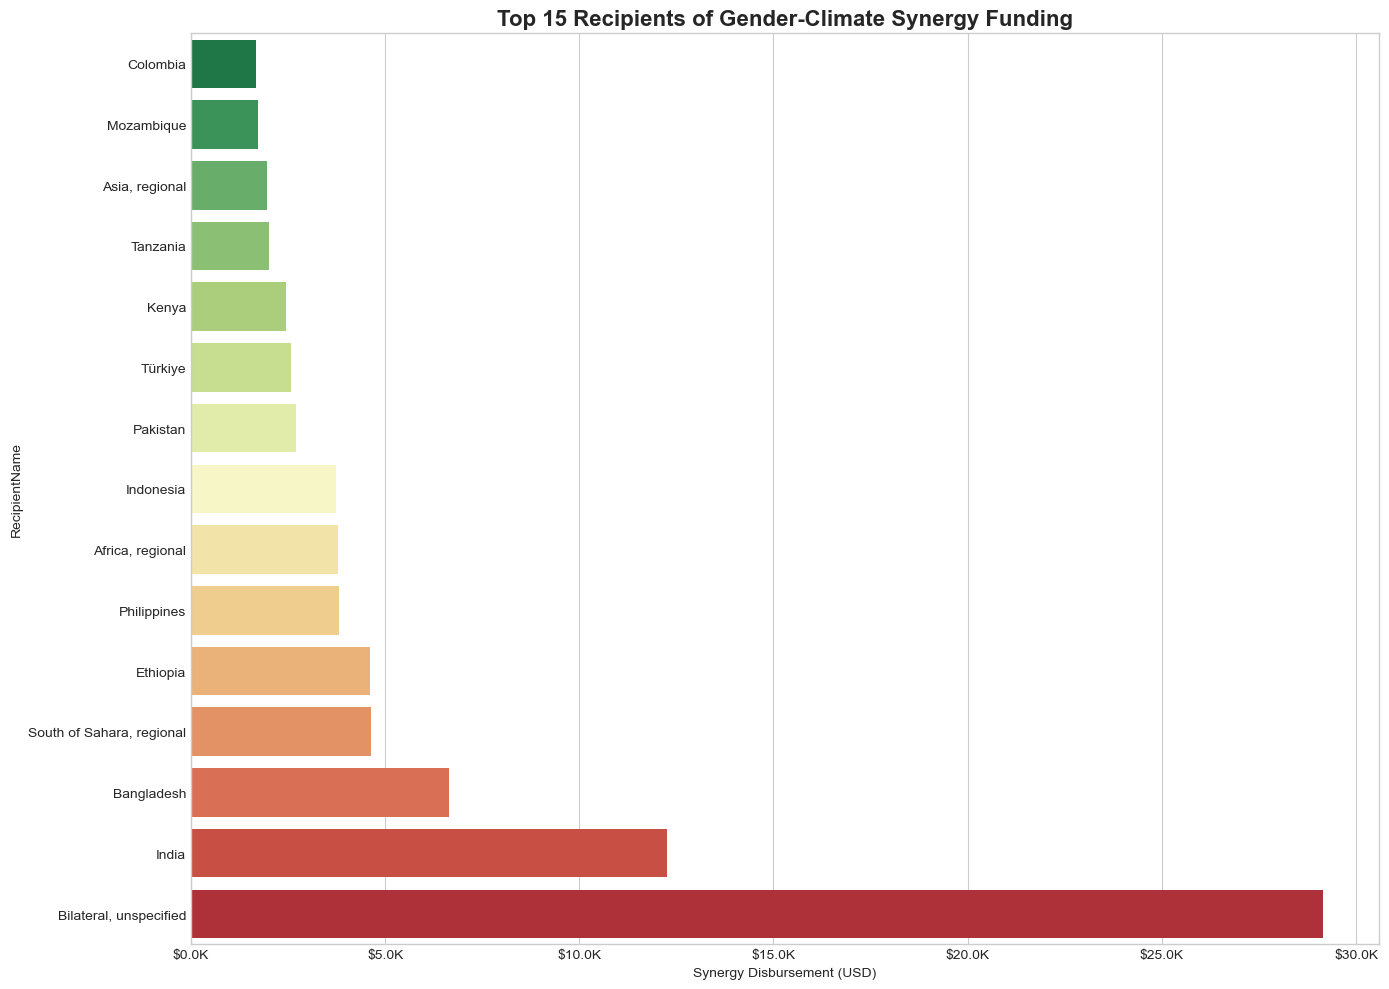

✓ Analyzed 186 recipient countries
Top recipient: Bilateral, unspecified with $0.03M


In [49]:
# =============================================================================
# SECTION 5: GEOGRAPHIC ANALYSIS & HOTSPOT IDENTIFICATION
# =============================================================================

if crs_data is not None:
    print("\n6. GEOGRAPHIC HOTSPOT ANALYSIS")
    
    
    if 'RecipientName' in crs_data.columns:
        # Country-level synergy analysis
        country_analysis = crs_data.groupby('RecipientName').agg({
            'USD_Disbursement': 'sum',
            'Synergy_Marker': 'sum',
            'Synergy_Score': 'mean',
            'Gender_Marker': 'sum',
            'Climate_Marker': 'sum'
        }).reset_index()
        
        # Calculate synergy metrics
        country_analysis['Synergy_Disbursement'] = crs_data[crs_data['Synergy_Marker'] == 1].groupby('RecipientName')['USD_Disbursement'].sum().values
        country_analysis['Synergy_Disbursement'] = country_analysis['Synergy_Disbursement'].fillna(0)
        
        # Get the actual top 15 recipients by Synergy_Disbursement
        top_synergy_countries = (
            country_analysis
            .sort_values('Synergy_Disbursement', ascending=False)  # Sort descending to get true top 15
            .head(15)
            .sort_values('Synergy_Disbursement', ascending=True)  # Sort ascending for proper bar order
        )
        
        plt.figure(figsize=(14, 10))
        ax = sns.barplot(
            data=top_synergy_countries,
            y='RecipientName', 
            x='Synergy_Disbursement', 
            palette='RdYlGn_r',
            order=top_synergy_countries['RecipientName']  # Explicit order to prevent sorting issues
        )
        
        plt.title('Top 15 Recipients of Gender-Climate Synergy Funding', 
                fontsize=16, weight='bold')
        plt.xlabel('Synergy Disbursement (USD)')
        
        # Dynamic scaling for x-axis
        max_value = top_synergy_countries['Synergy_Disbursement'].max()
        if max_value < 1_000_000:
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x/1e3:.1f}K'))
        else:
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M'))
            
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Analyzed {len(country_analysis)} recipient countries")
        print(f"Top recipient: {top_synergy_countries['RecipientName'].iloc[-1]} with ${max_value/1e6:.2f}M")


7. ADVANCED PATTERN ANALYSIS FOR ML FEATURES
--------------------------------------------------


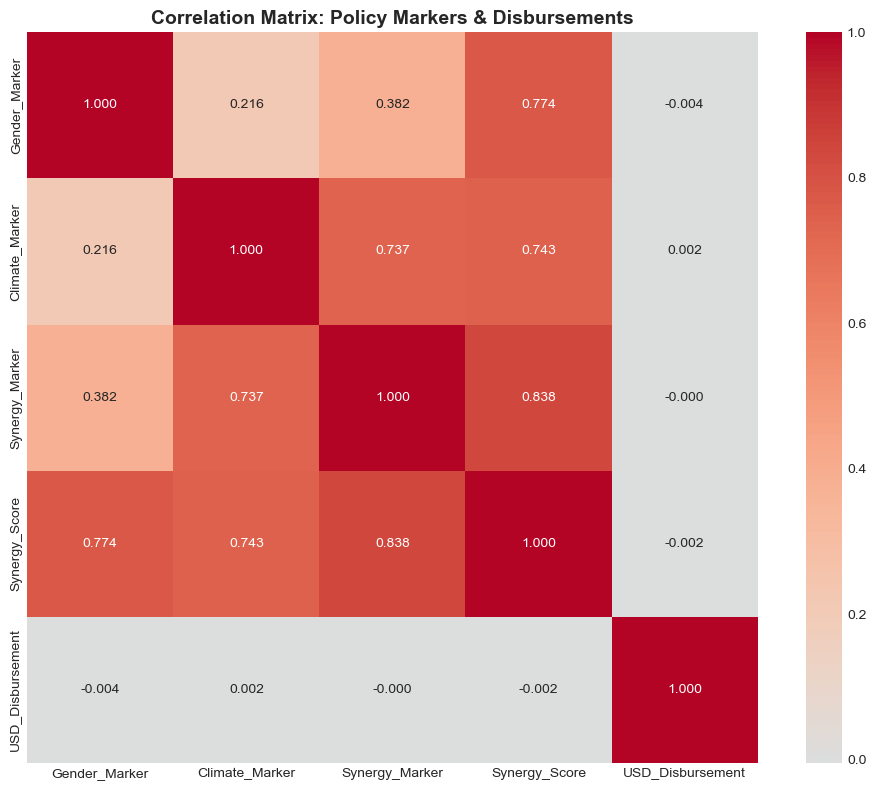

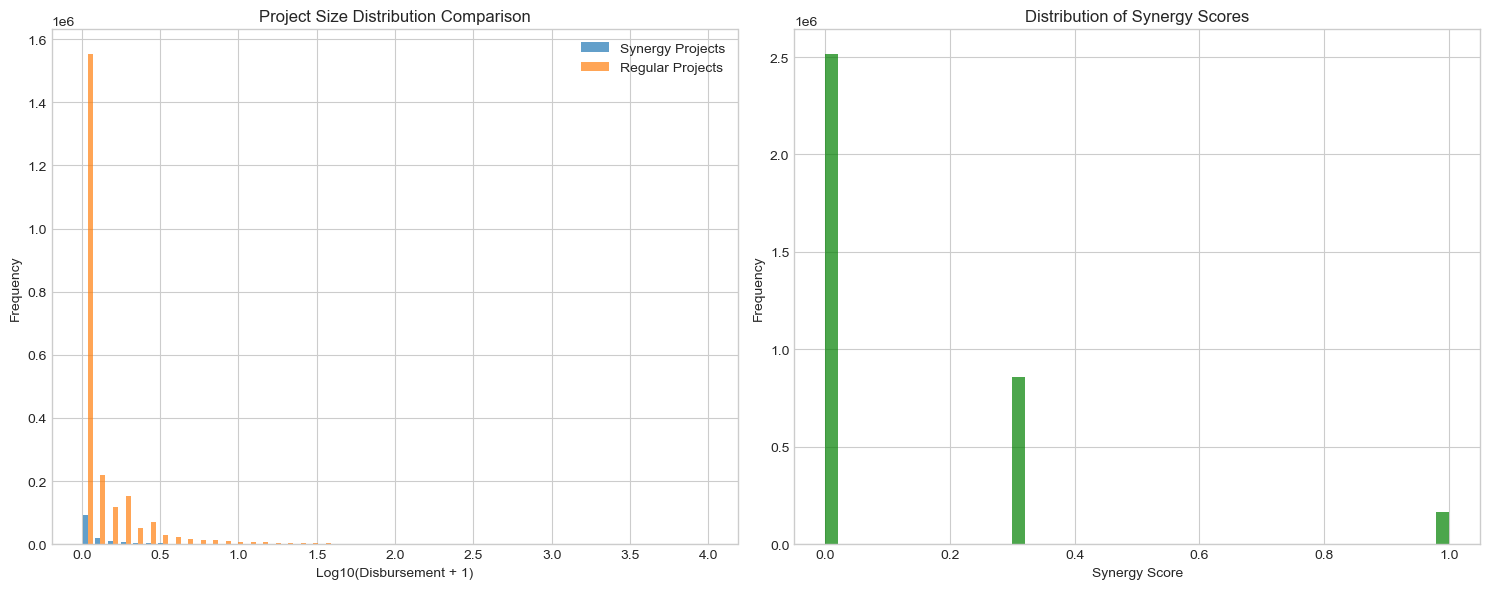

In [50]:
# =============================================================================
# SECTION 6: ADVANCED PATTERN ANALYSIS FOR ML FEATURES
# =============================================================================

if crs_data is not None:
    print("\n7. ADVANCED PATTERN ANALYSIS FOR ML FEATURES")
    print("-" * 50)
    
    # Correlation analysis between markers
    marker_cols = ['Gender_Marker', 'Climate_Marker', 'Synergy_Marker', 'Synergy_Score']
    if all(col in crs_data.columns for col in marker_cols):
        
        correlation_matrix = crs_data[marker_cols + ['USD_Disbursement']].corr()
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                   square=True, fmt='.3f')
        plt.title('Correlation Matrix: Policy Markers & Disbursements', 
                 fontsize=14, weight='bold')
        plt.tight_layout()
        plt.show()
    
    # Project size distribution analysis
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    synergy_amounts = crs_data[crs_data['Synergy_Marker'] == 1]['USD_Disbursement']
    regular_amounts = crs_data[crs_data['Synergy_Marker'] == 0]['USD_Disbursement']
    
    plt.hist([np.log10(synergy_amounts[synergy_amounts > 0] + 1), 
              np.log10(regular_amounts[regular_amounts > 0] + 1)], 
             bins=50, alpha=0.7, label=['Synergy Projects', 'Regular Projects'])
    plt.xlabel('Log10(Disbursement + 1)')
    plt.ylabel('Frequency')
    plt.title('Project Size Distribution Comparison')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    # Synergy score distribution
    plt.hist(crs_data['Synergy_Score'], bins=50, alpha=0.7, color='green')
    plt.xlabel('Synergy Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of Synergy Scores')
    
    plt.tight_layout()
    plt.show()

In [54]:
# =============================================================================
# SECTION 7: DATA INTEGRATION PREPARATION
# =============================================================================

print("\n8. DATA INTEGRATION PREPARATION")
print("-" * 50)

integration_summary = {
    'crs_countries': set(),
    'gain_countries': set(), 
    'undp_countries': set(),
    'ccvi_countries': set()
}

if crs_data is not None:
    if 'RecipientName' in crs_data.columns:
        integration_summary['crs_countries'] = set(crs_data['RecipientName'].unique())
        print(f"CRS unique recipients: {len(integration_summary['crs_countries'])}")

for key, data in supplementary_data.items():
    if 'Name' in data.columns:
        integration_summary[f'{key}_countries'] = set(data['Name'].unique())
        print(f"{key.upper()} unique countries: {len(integration_summary[f'{key}_countries'])}")

# Country matching analysis
if len(integration_summary['crs_countries']) > 0:
    print("\nCountry matching analysis:")
    for key in ['gain_countries', 'undp_countries', 'ccvi_countries']:
        if len(integration_summary[key]) > 0:
            overlap = len(integration_summary['crs_countries'] & integration_summary[key])
            total_crs = len(integration_summary['crs_countries'])
            print(f"CRS-{key.split('_')[0].upper()} overlap: {overlap}/{total_crs} ({overlap/total_crs*100:.1f}%)")



8. DATA INTEGRATION PREPARATION
--------------------------------------------------
CRS unique recipients: 186
GAIN unique countries: 187
UNDP unique countries: 206
CCVI unique countries: 175

Country matching analysis:
CRS-GAIN overlap: 122/186 (65.6%)
CRS-UNDP overlap: 128/186 (68.8%)
CRS-CCVI overlap: 116/186 (62.4%)


# Data Aggregation

## Data Cleaning Strategy

### 1. Column Selection and Null Value Handling


In [ ]:
# Drop columns with >70% null values
null_percent = df.isnull().mean()
cols_to_drop = null_percent[null_percent > 0.7].index.tolist()
df_clean = df.drop(columns=cols_to_drop)

# Additional columns to drop based on relevance
irrelevant_cols = [
    'USD_Commitment_Defl', 'USD_Disbursement_Defl', 'USD_Received_Defl', 'USD_AmountUntied_Defl',
    'USD_AmountPartialTied_Defl', 'USD_Amounttied_Defl', 'USD_GrantEquiv', 'ParentChannelCode'
]
df_clean = df_clean.drop(columns=irrelevant_cols)

In [ ]:
df_clean['Gender'].unique()

* Gender col :
    - 1.0: Likely represents projects with gender-focused components

    - 0.0: Projects without gender components

    - 2.0: Could indicate "dual gender focus" or special cases (verify with documentation)

    - NaN: Missing data (common in CRS datasets)

In [ ]:
# Convert to binary (1=gender-related, 0=not)
# Gender Column:
# 0 = No gender component | 1 = Gender-focused | 2 = Special gender focus (if kept)
# NaN → 0 (assuming missing = non-gender)
df_clean['Gender'] = df_clean['Gender'].fillna(0)  # Treat missing as non-gender
df_clean['Gender'] = np.where(df_clean['Gender'] >= 1, 1, 0)  # Map 2.0 → 1

In [ ]:
# List of POTENTIAL date columns (some may be missing)
possible_date_cols = [
    'ExpectedStartDate', 'CompletionDate', 'CommitmentDate', 
    'Repaydate1', 'Repaydate2'
]

# Only process columns that actually exist in the DataFrame
date_cols = [col for col in possible_date_cols if col in df_clean.columns]

# Now safely convert to datetime
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

### 2. Data Type Standardization


In [ ]:
# Define all POTENTIAL financial columns (some may be missing)
potential_financial_cols = [
    'USD_Commitment', 'USD_Disbursement', 'USD_Received',
    'USD_AmountPartialTied', 'USD_Expert_Extended', 'USD_Export_Credit',
    'Commitment_National', 'Disbursement_National', 'GrantEquiv'
]

# Filter to only columns that actually exist in the DataFrame
financial_cols = [col for col in potential_financial_cols if col in df_clean.columns]

# Now safely process the existing columns
for col in financial_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)
    
    # Optional: Convert to integer if appropriate (no decimals)
    if df_clean[col].dropna().apply(float.is_integer).all():
        df_clean[col] = df_clean[col].astype('Int64')  # Uses pandas' nullable integer type

## 3.Data Organization for Analysis

### 1. Aggregation by Recipient Country and Year


In [ ]:
# Safe aggregation functions with empty group handling
def safe_mode(x):
    """Returns mode if exists, otherwise None"""
    modes = x.mode()
    return modes[0] if len(modes) > 0 else None

def safe_first(x):
    """Returns first non-null value if exists, otherwise None"""
    first = x.dropna()
    return first.iloc[0] if len(first) > 0 else None

agg_dict = {
    # Financial metrics
    'USD_Commitment': ['sum', 'mean'],
    'USD_Disbursement': ['sum', 'mean'],
    'USD_Received': ['sum', 'mean'],
    'ProjectNumber': 'count',
    
    # Gender metrics
    'Gender': [
        ('gender_focused_count', lambda x: (x == 1).sum()),
        ('gender_focused_perc', lambda x: (x == 1).mean()),
        ('gender_focused_amount', lambda x: df_clean.loc[x.index, 'USD_Commitment'][x == 1].sum())
    ],
    
    # Climate/environment
    'Environment': ['sum', 'mean'],
    'ClimateMitigation': ['sum', 'mean'],
    'ClimateAdaptation': [
        ('climate_adaptation_count', lambda x: (x == 1).sum()),
        ('climate_adaptation_perc', lambda x: (x == 1).mean())
    ],
    
    # Sector information
    'SectorName': [
        ('primary_sector', safe_mode),
        ('sector_diversity', 'nunique')
    ],
    
    # String columns
    'RecipientName': safe_first,
    'RegionName': safe_first,
    'IncomegroupName': safe_first,
    
    # SDG information
    'SDGfocus': [
        ('sdg_count', 'size'),
        ('primary_sdg', safe_mode)
    ]
}

# Perform aggregation with error handling
try:
    agg_results = df_clean.groupby(['DERecipientcode', 'Year']).agg(agg_dict)
    
    # Flatten columns and handle empty results
    if len(agg_results) > 0:
        agg_results.columns = ['_'.join(col).strip() for col in agg_results.columns.values]
    else:
        # Create empty DataFrame with expected columns if no results
        expected_cols = [
            'USD_Commitment_sum', 'USD_Commitment_mean',
            'Gender_gender_focused_count', 'Gender_gender_focused_perc',
            # ... include all expected column names
        ]
        agg_results = pd.DataFrame(columns=expected_cols)
        
except Exception as e:
    print(f"Aggregation failed: {str(e)}")
    # Fallback to empty DataFrame
    agg_results = pd.DataFrame()

# Post-processing if we got results
if not agg_results.empty:
    # Rename columns
    agg_results = agg_results.rename(columns={
        'DERecipientcode': 'iso3',
        'ProjectNumber_count': 'ProjectCount'
    })
    
    # Calculate derived metrics
    agg_results['Gender_PerProject'] = (
        agg_results['Gender_gender_focused_count'] / 
        agg_results['ProjectCount'].replace(0, 1)  # Avoid division by zero
    )
    
    # Type conversion
    float_cols = [col for col in agg_results.columns if any(x in col for x in ['sum', 'mean', 'perc'])]
    for col in float_cols:
        agg_results[col] = pd.to_numeric(agg_results[col], errors='coerce').fillna(0).astype('float32')
    
    agg_results['ProjectCount'] = agg_results['ProjectCount'].fillna(0).astype('int32')
    
    # Reset index
    agg_results = agg_results.reset_index()

Three complementary metrics:

- gender_focused_count: Absolute number of gender-focused projects

- gender_focused_perc: Percentage of gender-focused projects (equivalent to mean)

- gender_focused_amount: Total funding for gender-focused projects

In [ ]:
#####################
#  Data Aggregation 
####################

import dask.dataframe as dd
from dask.diagnostics import ProgressBar

def load_and_merge_aggregated(crs_agg_path, ccvi_path, hdr_path, nd_gain_path, output_path):
    """
    Final robust merge function with exact column handling
    """
    print("🔄 Loading datasets with precise column mapping...")
    
    # 1. Load CRS data (already aggregated)
    crs_agg = pd.read_csv(crs_agg_path).rename(columns={
        'DERecipientcode': 'iso3',
        'RecipientName_safe_first': 'country_name'
    }).drop(columns=['Unnamed: 0'])

    # 2. Create country-year reference grid
    countries = crs_agg['iso3'].unique()
    years = range(2014, 2024)
    country_years = pd.DataFrame(
        [(iso3, year) for iso3 in countries for year in years],
        columns=['iso3', 'Year']
    )

    # 3. Load and prepare CCVI data
    ccvi = pd.read_csv(ccvi_path).rename(columns={
        'year': 'Year',
        'Name': 'country_name_ccvi'
    })[['iso3', 'Year', 'CCVI', 'CON_risk', 'CLI_risk', 'country_name_ccvi']]

    # 4. Load and prepare HDR data
    hdr = pd.read_csv(hdr_path).rename(columns={
        'CountryCode': 'iso3'
    })[['iso3', 'Year', 'gdi', 'gii', 'hdi', 'hdicode']]

    # 5. Load and prepare ND-GAIN data
    nd_gain = pd.read_csv(nd_gain_path).rename(columns={
        'ISO3': 'iso3'
    })[['iso3', 'Year', 'ND_GAIN_Score', 'Vulnerability', 'Readiness']]

    # 6. Execute merge sequence
    with ProgressBar():
        merged = (
            country_years
            .merge(crs_agg, on=['iso3', 'Year'], how='left')
            .merge(ccvi, on=['iso3', 'Year'], how='left')
            .merge(hdr, on=['iso3', 'Year'], how='left')
            .merge(nd_gain, on=['iso3', 'Year'], how='left')
        )
    
    # 7. Handle country names - CORRECTED VERSION
    if 'country_name_ccvi' in merged.columns:
        # Fill missing country names from CCVI data where available
        merged['country_name'] = merged['country_name'].combine_first(merged['country_name_ccvi'])
        merged = merged.drop(columns=['country_name_ccvi'])
    
    # 8. Type optimization
    float_cols = merged.select_dtypes(include='float64').columns
    merged[float_cols] = merged[float_cols].astype('float32')
    
    int_cols = ['Year', 'ProjectCount']
    for col in int_cols:
        if col in merged.columns:
            merged[col] = pd.to_numeric(merged[col], downcast='integer')
    
    # 9. Save optimized output
    merged.to_parquet(output_path, engine='pyarrow')
    
    
    
    return merged

if __name__ == "__main__":
    # Configuration paths
    config = {
        'crs_agg_path': 'data/processed/crs/crs_country_year_agg.csv',
        'ccvi_path': 'data/processed/ccvi/ccvi_annual_country.csv',
        'hdr_path': 'data/processed/undp_hdr/undp_hdr_data.csv', 
        'nd_gain_path': 'data/processed/ng_gain/nd_gain_data.csv',
        'output_path': 'data/processed/ccvi/optim_merged_development_data.parquet'
    }
    
    # Execute pipeline
    merged_data = load_and_merge_aggregated(**config)
    
    # Optional: Add feature engineering
    # merged_data = engineer_features(merged_data)

🔄 Loading datasets with precise column mapping...


In [40]:

########################
#  Advanced Feature Eng 
#######################

def engineer_features(df):
    """
    Enhanced feature engineering for the aggregated UNDP dataset with:
    - Vulnerability composites
    - Gender-climate synergies
    - Sector diversity metrics
    - SDG-focused features
    """
    print("🔧 Engineering enhanced features...")
    
    # =====================================================================
    # 1. MEMORY OPTIMIZATION
    # =====================================================================
    # Downcast numeric columns
    for col in df.select_dtypes(include=['float64']):
        df[col] = pd.to_numeric(df[col], downcast='float')
    for col in df.select_dtypes(include=['int64']):
        df[col] = pd.to_numeric(df[col], downcast='integer')
    
    # Convert categoricals
    cat_cols = ['SectorName_primary_sector', 'SDGfocus_primary_sdg', 'region']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    # =====================================================================
    # 2. VULNERABILITY COMPOSITES (Updated)
    # =====================================================================
    vuln_metrics = []
    if 'CCVI' in df.columns:
        vuln_metrics.append('CCVI')
    if 'CON_risk' in df.columns:
        vuln_metrics.append('CON_risk')
    if 'CLI_risk' in df.columns:
        vuln_metrics.append('CLI_risk')
    if 'Vulnerability' in df.columns:
        vuln_metrics.append('Vulnerability')
    
    if vuln_metrics:
        # Normalize each metric first
        normalized = df[vuln_metrics].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
        
        # Apply weights (CCVI gets 2x weight)
        weights = [2.0 if m == 'CCVI' else 1.0 for m in vuln_metrics]
        weighted = normalized.mul(weights, axis=1)
        
        # Create composite
        df['composite_vulnerability'] = weighted.mean(axis=1)
    
    # =====================================================================
    # 3. GENDER-CLIMATE SYNERGY FEATURES (Enhanced)
    # =====================================================================
    # Create unified climate marker
    climate_conditions = [
        (df['ClimateMitigation_mean'] > 0) | 
        (df['ClimateAdaptation_climate_adaptation_count'] > 0),
        (df['Environment_mean'] > 0)
    ]
    df['Climate_Intensity'] = np.select(
        climate_conditions, 
        [1.0, 0.5], 
        default=0.0
    )
    
    # Gender-climate synergy index
    df['Gender_Climate_Synergy'] = (
        df['Gender_gender_focused_perc'] * 
        df['Climate_Intensity'] * 
        np.log1p(df['USD_Commitment_sum'])
    )
    
    # =====================================================================
    # 4. SECTOR & SDG FEATURES (New)
    # =====================================================================
    # Sector concentration index (0-1)
    if 'SectorName_sector_diversity' in df.columns:
        max_diversity = df.groupby('Year')['SectorName_sector_diversity'].transform('max')
        df['Sector_Concentration'] = 1 - (df['SectorName_sector_diversity'] / max_diversity.replace(0, 1))
    
    # SDG alignment score
    if 'SDGfocus_sdg_count' in df.columns:
        df['SDG_Alignment'] = (
            df['SDGfocus_sdg_count'] / 
            df['ProjectCount'].replace(0, 1)
        )
    
    # =====================================================================
    # 5. READINESS-VULNERABILITY MATRIX (New)
    # =====================================================================
    if all(col in df.columns for col in ['Vulnerability', 'Readiness']):
        df['Vulnerability_Quartile'] = pd.qcut(
            df['Vulnerability'], 
            4, 
            labels=['Low', 'Medium', 'High', 'Extreme']
        )
        df['Readiness_Quartile'] = pd.qcut(
            df['Readiness'], 
            4, 
            labels=['Low', 'Medium', 'High', 'Very High']
        )
        df['Vuln_Readiness_Profile'] = (
            df['Vulnerability_Quartile'].astype(str) + "_" + 
            df['Readiness_Quartile'].astype(str)
        )
    
    # =====================================================================
    # 6. FINANCIAL EFFICIENCY METRICS (Enhanced)
    # =====================================================================
    # Commitment-to-disbursement ratio
    df['Commitment_Efficiency'] = (
        df['USD_Disbursement_sum'] / 
        df['USD_Commitment_sum'].replace(0, np.nan)
    )
    
    # Gender-focused dollars per capita
    if 'EXP_pop_count_raw' in df.columns:
        df['Gender_Investment_PC'] = (
            df['Gender_gender_focused_amount'] / 
            df['EXP_pop_count_raw'].replace(0, 1)
        )
    return df




In [43]:
# =============================================================================
# 3: ISO3-BASED ANALYSIS & VISUALIZATIONS (UPDATED)
# =============================================================================
import plotly.express as px

def create_country_summary(df):
    """
    Create country-level summary using ISO3 codes (updated for actual columns)
    """
    print("📈 Creating ISO3-based country summary...")
    
    # Verify available columns
    print("Available columns:", df.columns.tolist())
    
    # Updated aggregation dictionary using ONLY columns that exist
    agg_dict = {
        'USD_Commitment_sum': ['sum', 'count'],
        'USD_Disbursement_sum': 'sum',
        'Gender_gender_focused_perc': 'mean',
        'country_name': 'first'
    }
    
    # Add available indicators (only if they exist)
    potential_cols = [
        'CCVI', 'CON_risk', 'CLI_risk', 'Vulnerability', 'Readiness',
        'ND_GAIN_Score', 'gdi', 'gii', 'hdi', 'hdicode',
        'RegionName_safe_first', 'Climate_Intensity', 'Gender_Climate_Synergy'
    ]
    
    for col in potential_cols:
        if col in df.columns:
            agg_dict[col] = 'mean' if df[col].dtype in ['float64', 'float32', 'int64', 'int32'] else 'first'
    
    country_summary = df.groupby('iso3').agg(agg_dict)
    country_summary.columns = ['_'.join(col).strip() for col in country_summary.columns]
    country_summary = country_summary.reset_index()
    
    # Calculate additional metrics only if components exist
    if 'Vulnerability_mean' in country_summary.columns:
        country_summary['aid_per_vulnerability'] = (
            country_summary['USD_Commitment_sum_sum'] / 
            (country_summary['Vulnerability_mean'] + 0.01)  # Avoid division by zero
        )
    
    return country_summary

def create_visualizations(summary_df):
    """
    Create visualizations using available columns
    """
    print("📊 Creating visualizations with available columns:", summary_df.columns.tolist())
    
    figures = []
    
    # 1. Gender-Focused Aid World Map (if columns exist)
    if all(col in summary_df.columns for col in ['iso3', 'Gender_gender_focused_perc_mean', 'country_name_first']):
        fig1 = px.choropleth(
            summary_df,
            locations='iso3',
            color='Gender_gender_focused_perc_mean',
            hover_name='country_name_first',
            color_continuous_scale='RdYlGn',
            title='Percentage of Gender-Focused Aid by Country'
        )
        figures.append(fig1)
    
    # 2. Climate vs Gender Synergy (if columns exist)
    if all(col in summary_df.columns for col in ['Climate_Intensity_mean', 'Gender_Climate_Synergy_mean', 'country_name_first']):
        fig2 = px.scatter(
            summary_df,
            x='Climate_Intensity_mean',
            y='Gender_Climate_Synergy_mean',
            size='USD_Commitment_sum_sum',
            hover_name='country_name_first',
            title='Climate Intensity vs Gender-Climate Synergy'
        )
        figures.append(fig2)
    
    # 3. Vulnerability vs Aid (if columns exist)
    if all(col in summary_df.columns for col in ['Vulnerability_mean', 'USD_Commitment_sum_sum', 'country_name_first']):
        fig3 = px.scatter(
            summary_df,
            x='Vulnerability_mean',
            y='USD_Commitment_sum_sum',
            color='RegionName_safe_first_mean' if 'RegionName_safe_first_mean' in summary_df.columns else None,
            hover_name='country_name_first',
            title='Aid Allocation vs Climate Vulnerability'
        )
        figures.append(fig3)
    
    return figures


In [ ]:
# =============================================================================
# EXECUTION PIPELINE
# =============================================================================

if __name__ == "__main__":
    try:
        # Load merged data
        df = pd.read_parquet('/Users/hayat/Programming/ML/undp/data/optim_merged_development_data.parquet')
       
        
        # Feature engineering
        if 'engineer_features' in globals():
            df = engineer_features(df)
           
        
        # Country-level analysis
        country_summary = create_country_summary(df)
        
        
        # Create visualizations
        figures = create_visualizations(country_summary)
        
        # Display figures
        for i, fig in enumerate(figures, 1):
            print(f"\nDisplaying Figure {i}...")
            fig.show()
        
        # Save results
        country_summary.to_csv('/Users/hayat/Programming/ML/undp/data/country_summary_iso3.csv', index=False)
        df.to_parquet('/Users/hayat/Programming/ML/undp/data/final_engineered_data.parquet')
        
        
        print("Full dataset saved to: final_engineered_data.parquet")
        
    except Exception as e:
        print(f"❌ Error occurred: {str(e)}")
        print("Debugging info:")
        if 'df' in locals():
            print("DataFrame columns:", df.columns.tolist())

#### Keeping Only Record for countries not other Orgs

In [54]:
import pycountry

In [ ]:
def filter_country_level_data(df):
    """
    Filters dataset to keep only country-level records by validating ISO3 codes.
    Returns a cleaned DataFrame and saves both country and non-country datasets.
    """
    # Get list of valid country ISO3 codes
    valid_iso3 = {country.alpha_3 for country in pycountry.countries}
    
    # Create masks
    is_country = df['iso3'].isin(valid_iso3)
    non_country = ~is_country
    
    # Split datasets
    country_df = df[is_country].copy()
    org_df = df[non_country].copy()
    
    # Add country name from pycountry (more reliable than source data)
    def get_country_name(iso3):
        try:
            return pycountry.countries.get(alpha_3=iso3).name
        except:
            return None
    
    country_df['country_name_verified'] = country_df['iso3'].apply(get_country_name)
    
    # Save separated datasets
    country_df.to_parquet('/Users/hayat/Programming/ML/undp/data/country_level_data.parquet')
    org_df.to_parquet('/Users/hayat/Programming/ML/undp/data/organization_level_data.parquet')
    
    
    return country_df

In [ ]:
# Data for 145 unique countries
df_final = pd.read_csv('data/final_composed/final_composite.csv')

In [59]:
# After running filter_country_level_data()
print("\n🔍 Data Validation:")

# 1. Check time range
print(f"Year range: {df_final['Year'].min()} to {df_final['Year'].max()}")

# 2. Check records per country
records_per_country = df_final.groupby('iso3').size()
print(f"\nRecords per country statistics:")
print(records_per_country.describe())

# 3. Show countries with incomplete time series
incomplete = records_per_country[records_per_country < 10]  # Less than 10 years
print(f"\nCountries with incomplete data ({len(incomplete)}):")
print(incomplete.sort_values().head())


🔍 Data Validation:
Year range: 2014 to 2023

Records per country statistics:
count    145.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
dtype: float64

Countries with incomplete data (0):
Series([], dtype: int64)


# Advanced Data Analysis (Maps)

In [ ]:

# Load and prepare data
latest_year = df_final['Year'].max()
df_map = df_final[df_final['Year'] == latest_year].copy()

# Clean data
df_map['USD_Commitment_sum'] = pd.to_numeric(df_map['USD_Commitment_sum'], errors='coerce').fillna(0)
df_map['Gender_Climate_Synergy'] = pd.to_numeric(df_map['Gender_Climate_Synergy'], errors='coerce').fillna(0)
df_map['composite_vulnerability'] = pd.to_numeric(df_map['composite_vulnerability'], errors='coerce').fillna(0)

# Create the map with FIXED hover names (key change)
fig_map = px.scatter_geo(
    df_map,
    locations="iso3",
    hover_name="country_name",  # Using original column directly
    size="USD_Commitment_sum",
    color="Gender_Climate_Synergy",
    custom_data=['composite_vulnerability', 'USD_Commitment_sum', 'iso3', 'country_name'],
    projection="natural earth",
    title=f"<b>Climate-Gender Synergy vs. Funding ({latest_year})</b><br>"
          "<sup>Size = Funding | Color = Synergy (0=Low, 1=High)</sup>",
    color_continuous_scale=px.colors.diverging.RdYlGn,
    size_max=50,
    template="plotly_dark"
)

# Enhanced hover template (modified to use custom_data)
fig_map.update_traces(
    hovertemplate=(
        "<b>%{customdata[3]}</b><br>"
        "ISO3: %{customdata[2]}<br>"
        "Synergy Score: %{color:.2f}<br>"
        "Vulnerability Index: %{customdata[0]:.2f}<br>"
        "Total Funding: $%{customdata[1]:,.0f}<br>"
        "<extra></extra>"
    )
)

# Professional layout adjustments (identical to first version)
fig_map.update_layout(
    coloraxis_colorbar={
        "title": "Synergy Score",
        "tickvals": [0, 0.25, 0.5, 0.75, 1],
        "ticktext": ["Low", "", "Medium", "", "High"]
    },
    geo={
        'showframe': False,
        'showcoastlines': True,
        'coastlinecolor': "LightGrey",
        'landcolor': "rgb(217, 217, 217)",
        'bgcolor': 'rgba(0,0,0,0)'
    },
    margin={"r":0,"t":80,"l":0,"b":0},
    font=dict(family="Arial", size=12)
)

# Save interactive map
fig_map.write_html("NEW_gender_climate_synergy_map.html")
print("Map saved successfully with fixed hover names!")

Map saved successfully with fixed hover names!


- **What the Plot Shows:**

    - Bubble Size: Represents total USD funding commitment to each country

    - Color Gradient: Shows the Gender-Climate Synergy Score (darker colors = higher synergy)

    - Geographic Distribution: Reveals regional patterns in gender-climate funding effectiveness

- **What Synergy Score Means:**

    - The Gender_Climate_Synergy score (range 0-1) measures how well a country's aid projects simultaneously address:

        - Gender equality (`Gender_gender_focused_perc`)

        - Climate action (`Climate_Intensity`)

- Higher scores (closer to 1) indicate projects that effectively combine gender and climate objectives

In [ ]:
df_scatter = df_final[df_final['Year'] == latest_year].copy()

# Ensure key columns are numeric
df_scatter['composite_vulnerability'] = pd.to_numeric(df_scatter['composite_vulnerability'], errors='coerce')
df_scatter['Gender_Climate_Synergy'] = pd.to_numeric(df_scatter['Gender_Climate_Synergy'], errors='coerce')
df_scatter['USD_Commitment_sum'] = pd.to_numeric(df_scatter['USD_Commitment_sum'], errors='coerce').fillna(0)


# --- Create the Scatter Plot ---
fig_scatter = px.scatter(
    df_scatter,
    x="composite_vulnerability",
    y="Gender_Climate_Synergy",
    size="USD_Commitment_sum",
    color="RegionName_safe_first",  # Color by region to identify regional patterns
    hover_name="country_name",
    size_max=60,
    log_x=False, # Use a linear scale for vulnerability unless it's highly skewed
    template="plotly_dark",
    title="Synergy Sweet Spots: Vulnerability vs. Climate-Gender Synergy"
)


# Add annotations to define actionable quadrants
fig_scatter.add_annotation(x=df_scatter['composite_vulnerability'].median(), y=df_scatter['Gender_Climate_Synergy'].max(),
            text="High Synergy, High Vulnerability (Target for replication)", showarrow=False, yshift=10)

fig_scatter.add_annotation(x=df_scatter['composite_vulnerability'].min(), y=df_scatter['Gender_Climate_Synergy'].min())


fig_scatter.update_layout(
    xaxis_title="Composite Vulnerability Index",
    yaxis_title="Gender-Climate Synergy Score",
    legend_title="Region"
)

# Save the plot as a self-contained HTML file
fig_scatter.write_html("synergy_sweet_spots_scatter.html")

print("Interactive scatter plot saved as synergy_sweet_spots_scatter.html")


Interactive scatter plot saved as synergy_sweet_spots_scatter.html


In [ ]:

# Load and prepare data
latest_year = df_final['Year'].max()
df_map = df_final[df_final['Year'] == latest_year].copy()

# Data cleaning and transformations
df_map['USD_Commitment_sum'] = pd.to_numeric(df_map['USD_Commitment_sum'], errors='coerce').fillna(0)
df_map['Gender_Climate_Synergy'] = pd.to_numeric(df_map['Gender_Climate_Synergy'], errors='coerce').clip(0, 6)
df_map['composite_vulnerability'] = pd.to_numeric(df_map['composite_vulnerability'], errors='coerce').fillna(0)

# Calculate bubble sizes (with non-zero minimum)
size_min = df_map[df_map['USD_Commitment_sum'] > 0]['USD_Commitment_sum'].min()
df_map['bubble_size'] = df_map['USD_Commitment_sum'].apply(
    lambda x: max(x, size_min/10) if x > 0 else 0
)

# Create the visualization
fig_map = px.scatter_geo(
    df_map[df_map['bubble_size'] > 0],  # Only show funded countries
    locations="iso3",
    hover_name="country_name_verified",
    size="bubble_size",
    size_max=30,
    color="Gender_Climate_Synergy",
    color_continuous_scale=px.colors.sequential.Plasma,
    range_color=[0, 6],
    custom_data=['composite_vulnerability', 'USD_Commitment_sum', 'Gender_Climate_Synergy', 'iso3'],
    projection="natural earth",
    title=f"<b>Gender-Climate Synergy Analysis ({latest_year})</b><br>"
          "<sup>Bubble Size = Total Funding | Color = Synergy Score (0-6)</sup>",
    template="plotly_dark"
)

# Enhanced hover information
fig_map.update_traces(
    hovertemplate=(
        "<b>%{hovertext}</b> (%{customdata[3]})<br><br>"
        "Synergy Score: <b>%{customdata[2]:.2f}/6</b><br>"
        "Vulnerability Index: %{customdata[0]:.2f}<br>"
        "Total Funding: <b>$%{customdata[1]:,.0f}</b><br>"
        "<extra></extra>"
    ),
    marker=dict(
        sizemode='area',
        sizeref=2.*max(df_map['bubble_size'])/(30.**2),
        line=dict(width=0.5, color='DarkSlateGrey')
)
)
# Professional layout adjustments
fig_map.update_layout(
    coloraxis_colorbar={
        "title": "Synergy<br>Score",
        "x": 0.85,  # Position adjustment
        "tickvals": [0, 1, 2, 3, 4, 5, 6],
        "ticktext": ["0", "1", "2", "3", "4", "5", "6"]
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="Darkgray",
        landcolor="rgba(240,240,240,0.7)",
        bgcolor='rgba(255,255,255,0.1)'
    ),
    margin={"r":0,"t":100,"l":0,"b":0},
    font=dict(family="Arial", size=12),
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)

# Add annotation with data source
fig_map.add_annotation(
    x=0.1,
    y=0.05,
    xref="paper",
    yref="paper",
    text="Source: UNDP Development Data",
    showarrow=False,
    font=dict(size=10, color="grey")
)

# Save as HTML with additional parameters for better mobile viewing
fig_map.write_html(
    "gender_climate_synergy_map.html",
    full_html=True,
    include_plotlyjs='cdn',  # Uses CDN for smaller file size
    config={
        'responsive': True,
        'displayModeBar': True,
        'scrollZoom': True
    }
)


print(f"Countries displayed: {len(df_map[df_map['bubble_size'] > 0])}")
print(f"Synergy score range: {df_map['Gender_Climate_Synergy'].min():.2f}-{df_map['Gender_Climate_Synergy'].max():.2f}")

✅ Interactive map saved as 'gender_climate_synergy_map.html'
Countries displayed: 140
Synergy score range: 0.04-5.40


## Doner-specific flow analysis (Korea)

In [ ]:
crs_cleaned = pd.read_parquet('crs_cleaned.parquet')

In [ ]:
df_final['USD_Commitment_sum'].sample(n=5)

In [ ]:

# 4. Filter for donor: Korea
korea_df = crs_cleaned[crs_cleaned['DEDonorcode'].str.contains('Korea|Republic of Korea|KOR')]

# Optional: merge iso3/country_name from final dataset
korea_df = korea_df.merge(df_final[['iso3', 'country_name_verified']], left_on='RecipientName', right_on='country_name_verified', how='left')

In [ ]:
 # Remove rows where BOTH columns are NaN
korea_df_cleaned = korea_df.dropna(
    subset=['iso3', 'country_name_verified'],
    how='all'  # Only drop if BOTH are NaN
)

# Verify removal
print(f"Original rows: {len(korea_df)}")
print(f"Cleaned rows: {len(korea_df_cleaned)}")
print(f"Removed {len(korea_df) - len(korea_df_cleaned)} rows")

Original rows: 528353
Cleaned rows: 503910
Removed 24443 rows


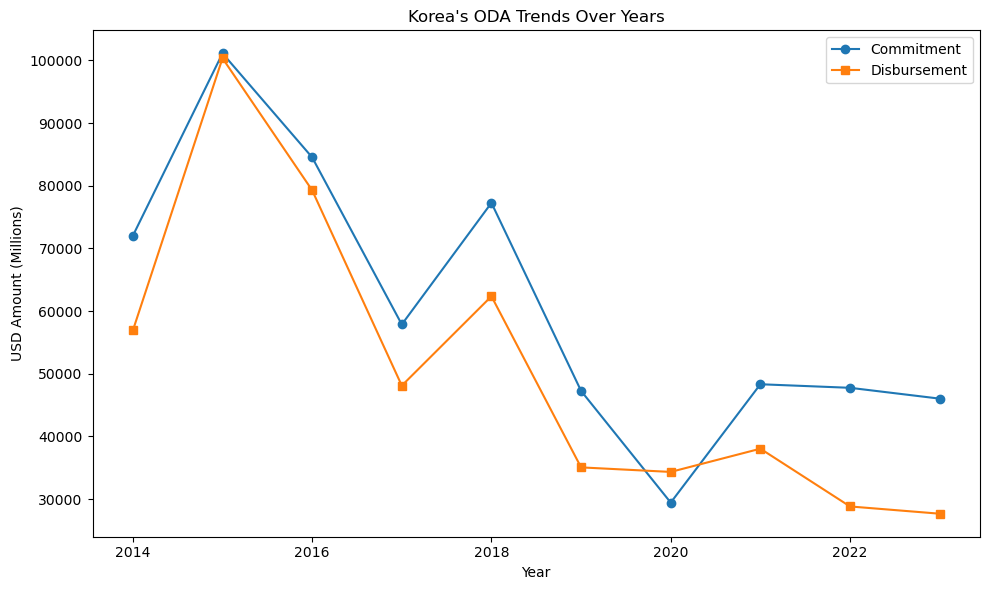

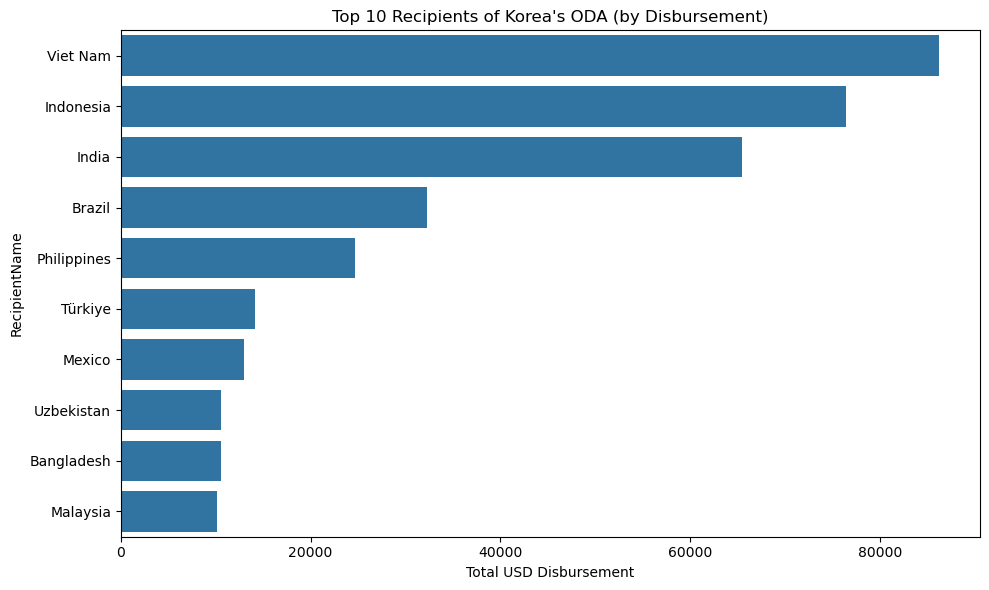

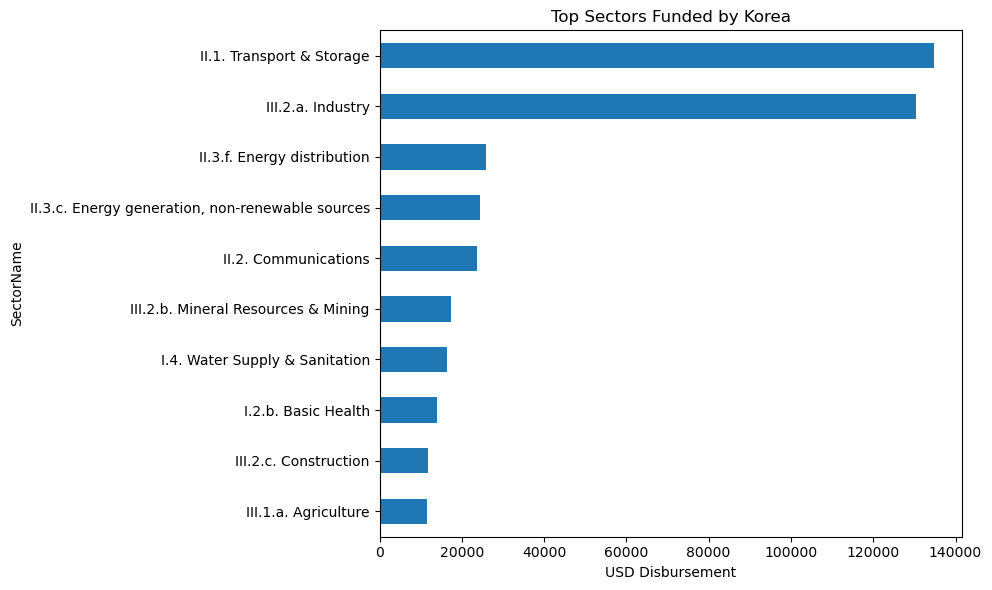

In [ ]:
# --- Analysis 1: Yearly trends of Korea's ODA ---
korea_yearly = korea_df_cleaned.groupby('Year')[['USD_Commitment', 'USD_Disbursement']].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(korea_yearly['Year'], korea_yearly['USD_Commitment'], marker='o', label='Commitment')
plt.plot(korea_yearly['Year'], korea_yearly['USD_Disbursement'], marker='s', label='Disbursement')
plt.title("Korea's ODA Trends Over Years")
plt.xlabel("Year")
plt.ylabel("USD Amount (Millions)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Analysis 2: Top 10 recipient countries by amount ---
top_recipients = korea_df_cleaned.groupby('RecipientName')['USD_Disbursement'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_recipients.values, y=top_recipients.index)
plt.title("Top 10 Recipients of Korea's ODA (by Disbursement)")
plt.xlabel("Total USD Disbursement")
plt.tight_layout()
plt.show()

# --- Analysis 3: Sector distribution ---
sector_dist = korea_df_cleaned.groupby('SectorName')['USD_Disbursement'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sector_dist.plot(kind='barh')
plt.title("Top Sectors Funded by Korea")
plt.xlabel("USD Disbursement")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
